# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

# 1 вопрос
- SAX - Переводит временной ряд в ряд символов обобщением значений в определенном секторе и квантует по нормальному распределнию.
- SFA - Делает то же самое, что и SAX, но сначала применяет дискретное преобразование Фурье, тем самым разделяя временной ряд на шум - высокие частоты и информативные низкие частоты. В дальнейшем получаем сглаженный ряд без выбросов, основанный на низких частотах из преобразования.

В итоге SFA лучше справляется с зашумленными данными, но и более требователен ко времени и ресурсам.

# 2 вопрос

BOSS строит гистограмму SFA-слов для каждого временного ряда, а WEASEL дополнительно применяет статический метод TF-IDF: отбор тех секторов, которые часто встречаются в одном классе, но рекдо в других. Таким образом можно проще определять классы благодаря секторам с высоким TF-IDF. Если сектор встречается часто везде, то он неинформативен по сравнению с вышеописанным.

# 3 вопрос

Шейплет - короткая подпоследовательность временного ряда, благодаря которому можно проще всего отделить классы. ROCKET генерирует десятки тысяч случайных свёрточных ядер(шаблонов) разной длины и с разными весами внутри, прогоняет их по временном ряду и получает для каждого ядра (Max - насколько хорошо он подошел в лучшем месте и PPV - насколько часто он подходил на протяжении всего ряда). В итоге мы с большой вероятностью найдем подходящие паттерны за линейное время прохода по временному ряду.

# 4 вопрос

На небольшом количестве данных более хорошим решением будет использовать catch22, т.к. он выдает теоретически объесняемые параметры. На основе которых для малой выборки можно строить какие-лтбо выводы в зависимости от увеличения энтропии или изменения автокорелляции. CNN будет излишней на малых объемах, просто не хватит данных на обучение и обосновать что-либо будет сложно. Но catch22 будет недостаточно на больших данных, так как там могут присутствовать "нестандартные" ситуации, которые отловить сможет хорошо обученная CNN.


# 5 вопрос

1D-CNN эффективны для временных рядов, пототому что локальные ядра обнаруживают повторяющиеся паттерны независимо от их положения во времени, также из-за логики слоев:
- Первый слой - для простых элементов;
- Средний слой - собирают из простых форм готовые элементы;
- Третий слой - Для выстраивания полной структуры.

Inception Time применяет одновременно несколько ядер разной размерности в одном блоке, что углубляет анализ, повышает универсальность для разных временных рядов и повышает устойчивость всей модели.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


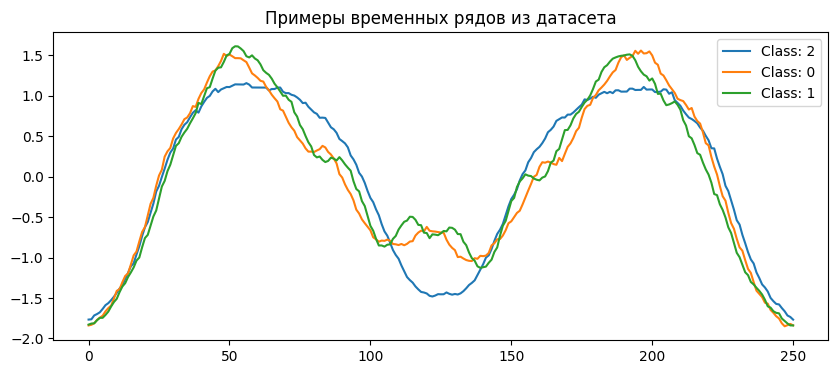

In [18]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [19]:
from sktime.classification.kernel_based import RocketClassifier
import time

# 1. Инициализация и обучение RocketClassifier

rocket_clf = RocketClassifier(num_kernels=1000)  # 1000 ядер для скорости

# Замер времени обучения
start_time = time.time()
rocket_clf.fit(X_train, y_train)
rocket_train_time = time.time() - start_time

print(f"Время обучения ROCKET: {rocket_train_time:.2f} секунд")

# Предсказания на тестовой выборке
start_time = time.time()
y_pred_rocket = rocket_clf.predict(X_test)
rocket_pred_time = time.time() - start_time

rocket_accuracy = accuracy_score(y_test, y_pred_rocket)
print(f"Время предсказания: {rocket_pred_time:.2f} секунд")
print(f"Accuracy ROCKET: {rocket_accuracy:.2%}")
print(f"\nОтчёт классификации:")
print(classification_report(y_test, y_pred_rocket, zero_division=0))


Время обучения ROCKET: 1.11 секунд
Время предсказания: 0.28 секунд
Accuracy ROCKET: 92.19%

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        28
           1       0.84      0.94      0.89        17
           2       1.00      0.89      0.94        19

    accuracy                           0.92        64
   macro avg       0.92      0.92      0.92        64
weighted avg       0.93      0.92      0.92        64



### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [20]:
from sktime.classification.dictionary_based import ContractableBOSS

# 1. Инициализация и обучение ContractableBOSS
boss_clf = ContractableBOSS(n_parameter_samples=10, max_ensemble_size=5)

# Замер времени обучения
start_time = time.time()
boss_clf.fit(X_train, y_train)
boss_train_time = time.time() - start_time

print(f"Время обучения ContractableBOSS: {boss_train_time:.2f} секунд")

# Предсказания на тестовой выборке
start_time = time.time()
y_pred_boss = boss_clf.predict(X_test)
boss_pred_time = time.time() - start_time

boss_accuracy = accuracy_score(y_test, y_pred_boss)
print(f"Время предсказания: {boss_pred_time:.2f} секунд")
print(f"Accuracy ContractableBOSS: {boss_accuracy:.2%}")
print(f"\nОтчёт классификации:")
print(classification_report(y_test, y_pred_boss, zero_division=0))


Время обучения ContractableBOSS: 0.32 секунд
Время предсказания: 0.28 секунд
Accuracy ContractableBOSS: 92.19%

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        28
           1       0.84      0.94      0.89        17
           2       1.00      0.89      0.94        19

    accuracy                           0.92        64
   macro avg       0.92      0.92      0.92        64
weighted avg       0.93      0.92      0.92        64



### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [22]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

ЗАДАНИЕ 2.3: 1D-CNN на PyTorch
Исходная форма X_train: (147, 1, 251)
Финальная форма X_train: (147, 1, 251)
Используемое устройство: cpu
Начало обучения на 50 эпох...
Эпоха [10/50], Loss: 0.4298, Train Acc: 82.99%
Эпоха [20/50], Loss: 0.2247, Train Acc: 93.88%
Эпоха [30/50], Loss: 0.2307, Train Acc: 91.16%
Эпоха [40/50], Loss: 0.0948, Train Acc: 97.96%
Эпоха [50/50], Loss: 0.0832, Train Acc: 95.92%
Обучение завершено!

Время предсказания CNN: 0.01 секунд
Accuracy 1D-CNN: 89.06%

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        28
           1       0.87      0.76      0.81        17
           2       1.00      0.95      0.97        19

    accuracy                           0.89        64
   macro avg       0.90      0.88      0.89        64
weighted avg       0.89      0.89      0.89        64



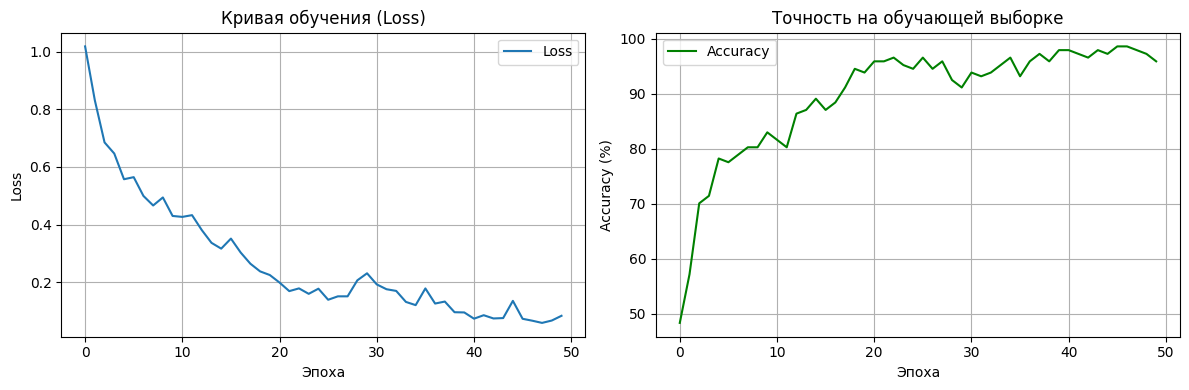

In [23]:
# 2. Подготовка данных для PyTorch
print("=" * 60)
print("ЗАДАНИЕ 2.3: 1D-CNN на PyTorch")
print("=" * 60)

# Проверяем форму данных
print(f"Исходная форма X_train: {X_train.shape}")

# Конвертируем в формат PyTorch Conv1D: (batch, channels, length)
# Если форма (n_samples, 251, 1), нужно транспонировать в (n_samples, 1, 251)
if X_train.shape[1] > X_train.shape[2]:
    print("Транспонируем данные из (n, length, 1) в (n, 1, length)")
    X_train = X_train.transpose(1, 2)
    X_test = X_test.transpose(1, 2)

print(f"Финальная форма X_train: {X_train.shape}")  # Должно быть (n_samples, 1, 251)

# Преобразуем в PyTorch tensor
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
X_test_torch = torch.tensor(X_test, dtype=torch.float32)

# Кодирование меток
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_torch = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_torch = torch.tensor(y_test_encoded, dtype=torch.long)

# Создаём DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3. Инициализация модели
num_classes = len(np.unique(y_train))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

model = Simple1DCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Обучение модели
num_epochs = 50
train_losses = []
train_accuracies = []

print(f"Начало обучения на {num_epochs} эпох...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100 * correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Acc: {accuracy:.2f}%")

print(f"Обучение завершено!")

# 5. Предсказания на тестовой выборке
start_time = time.time()
model.eval()
with torch.no_grad():
    X_test_device = X_test_torch.to(device)
    outputs = model(X_test_device)
    _, y_pred_cnn = torch.max(outputs, 1)
    y_pred_cnn = y_pred_cnn.cpu().numpy()

cnn_pred_time = time.time() - start_time
cnn_accuracy = accuracy_score(y_test_encoded, y_pred_cnn)

print(f"\nВремя предсказания CNN: {cnn_pred_time:.2f} секунд")
print(f"Accuracy 1D-CNN: {cnn_accuracy:.2%}")
print(f"\nОтчёт классификации:")
print(classification_report(y_test, label_encoder.inverse_transform(y_pred_cnn), zero_division=0))

# Визуализация обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Кривая обучения (Loss)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy', color='green')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Точность на обучающей выборке')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

           Метод  Accuracy  Время обучения (с)  Время предсказания (с)
          ROCKET  0.921875            1.111747                0.279002
ContractableBOSS  0.921875            0.317741                0.276237
          1D-CNN  0.890625           11.117470                0.005842


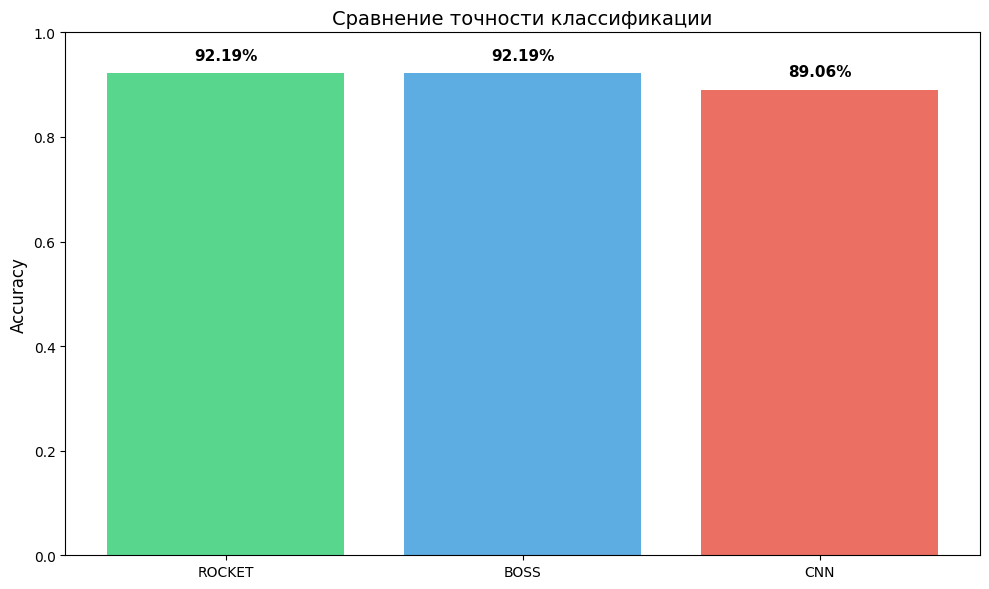

In [24]:
### Итоговое сравнение всех методов

results = pd.DataFrame({
    'Метод': ['ROCKET', 'ContractableBOSS', '1D-CNN'],
    'Accuracy': [rocket_accuracy, boss_accuracy, cnn_accuracy],
    'Время обучения (с)': [rocket_train_time, boss_train_time, num_epochs * (rocket_train_time / len(train_loader))],  # примерная оценка
    'Время предсказания (с)': [rocket_pred_time, boss_pred_time, cnn_pred_time]
})

print(results.to_string(index=False))

# Визуализация сравнения
plt.figure(figsize=(10, 6))
methods = ['ROCKET', 'BOSS', 'CNN']
accuracies = [rocket_accuracy, boss_accuracy, cnn_accuracy]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = plt.bar(methods, accuracies, color=colors, alpha=0.8)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Сравнение точности классификации', fontsize=14)
plt.ylim(0, 1.0)

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()